# Time-Resolved NAF — Metrics & Visualizations

Evaluates the temporal-basis neural implicit field (`sdate.tr_naf`) against the
**Sliding-Window FBP (SW-FBP)** baseline on a synthetic multi-sweep, limited-angle
acquisition.

The field maps each spatial voxel `(x,y,z)` to `K` cubic-B-spline coefficients
describing that voxel's **smooth attenuation curve over the scan**:
`mu(x,y,z,t) = softplus(sum_k c_k(x,y,z) * phi_k(t))`.

This notebook loads the checkpoints produced by `scripts/tr_naf_sweep.py`
(under `checkpoints/tr_naf/`). Set `TRAIN_IF_MISSING = True` to train a single
config inline if no checkpoints are found.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '/myhome/sdate')
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

from sdate.tr_naf import (
    load_result, reconstruct_volume_at, evaluate_frames, make_circular_mask,
    build_acquisition, sliding_window_fbp, tr_naf_reconstruction, save_result,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Pick which dataset's results to view. Each dataset is a subdir written by
# scripts/tr_naf_sweep.py (e.g. '212_Wunderkerze2', '149_ASM_SP_1ktps').
DATASET = '212_mid_skip0_pad'   # 50 frames (full horizon), K=6 + L1 TV + coarse grid + full boundaries
BASE = Path('/myhome/sdate/checkpoints/tr_naf')
CKPT = BASE / DATASET
if not (CKPT / 'acquisition.pt').exists() and (BASE / 'acquisition.pt').exists():
    CKPT = BASE            # fall back to a flat (single-dataset) layout
TRAIN_IF_MISSING = False
plt.rcParams['image.cmap'] = 'gray'
print('device:', device, '| dataset:', DATASET, '| checkpoints:', CKPT)

device: cuda | dataset: 212_mid_skip0_pad | checkpoints: /myhome/sdate/checkpoints/tr_naf/212_mid_skip0_pad


## 1. Load acquisition (GT + SW-FBP baseline) and trained runs

In [2]:
# --- shared acquisition bundle (ground-truth volumes + SW-FBP) ---
if not (CKPT / 'acquisition.pt').exists():
    if not TRAIN_IF_MISSING:
        raise FileNotFoundError('Run scripts/tr_naf_sweep.py first, or set TRAIN_IF_MISSING=True')
    # minimal inline build+train (single K) so the notebook is self-contained
    TIF = ('/myhome/data/sdate/shared/time_resolved/212_Wunderkerze2/timesteps/'
           '212_Wunderkerze2_rotate_04001.tif')
    frames, meta = build_acquisition(TIF, num_frames=25, angle_range_deg=36.0,
        num_full_projs=360, timestep_skip=5, cube_size=128,
        normalize_range=None, device=device)  # auto per-dataset min/max
    sw = sliding_window_fbp(frames, meta, device=device)
    CKPT.mkdir(parents=True, exist_ok=True)
    torch.save({'true_volumes': torch.stack([f.true_volume for f in frames]).cpu(),
                'times': [f.t_norm for f in frames], 'angles': [f.angles_deg for f in frames],
                'sw_fbp': sw.cpu(), 'meta': meta}, CKPT / 'acquisition.pt')
    res = tr_naf_reconstruction(frames, meta, K=6, n_iterations=1500, device=device, seed=0, verbose=True)
    save_result(res, meta, CKPT / 'K6.pt')

acq = torch.load(CKPT / 'acquisition.pt', map_location=device, weights_only=False)
true_vols = [v.to(device) for v in acq['true_volumes']]
times = acq['times']
# SW-FBP is a *dynamic* baseline: one volume per frame (T,X,Y,Z). Fall back to a
# repeated static volume if an older (X,Y,Z) bundle is loaded.
_sw = acq['sw_fbp'].to(device)
sw_vols = [_sw[i] for i in range(_sw.shape[0])] if _sw.ndim == 4 else [_sw] * len(true_vols)
meta = acq['meta']
CUBE = meta['cube_size']
mask = make_circular_mask(CUBE, CUBE, device=device)
print(f"{len(true_vols)} frames | {meta['num_sweeps']:.1f} sweeps | "
      f"{meta['num_la_projs']} projs/frame | cube={CUBE}")

62 frames | 12.4 sweeps | 72 projs/frame | cube=128


In [3]:
# --- load every trained K checkpoint ---
runs = {}   # K -> dict(coeffs..., recon list, metrics)
data_range = acq.get('data_range', None)
for p in sorted(CKPT.glob('K*.pt')):
    K = int(p.stem[1:])
    result, _ = load_result(p, device=device)
    recon = [reconstruct_volume_at(result, t) for t in times]
    m = evaluate_frames(recon, true_vols, mask=mask, data_range=data_range)
    data_range = m['data_range']
    runs[K] = {'result': result, 'recon': recon, 'metrics': m,
               'losses': result['losses']}
    print(f"loaded K={K}: PSNR {m['psnr'].mean():.2f} dB  SSIM {m['ssim'].mean():.4f}")

sw_metrics = evaluate_frames(sw_vols, true_vols, mask=mask, data_range=data_range)
Ks = sorted(runs)
print('\nK values:', Ks)

loaded K=12: PSNR 27.59 dB  SSIM 0.7295
loaded K=6: PSNR 26.99 dB  SSIM 0.7200
loaded K=8: PSNR 27.40 dB  SSIM 0.7263

K values: [6, 8, 12]


## 2. Summary metrics table (per-frame mean, circular-masked)

In [4]:
import pandas as pd
# Dynamics-fidelity metric: fraction of GT's per-voxel temporal range (max-min
# over time) that the reconstruction recovers, in the mask. ~100% = right amount
# of motion; <100% under-modeled (too smooth); >>100% spurious temporal noise.
_gt = torch.stack(true_vols)
_gt_range = float((_gt.amax(0) - _gt.amin(0))[:, mask].mean())
def range_pct(recon_list):
    r = torch.stack(recon_list)
    return 100.0 * float((r.amax(0) - r.amin(0))[:, mask].mean()) / _gt_range

rows = [{'model': 'SW-FBP (dynamic)',
         'PSNR (dB)': sw_metrics['psnr'].mean(),
         'SSIM': sw_metrics['ssim'].mean(),
         'rel-err': sw_metrics['rel_err'].mean(),
         'range %': range_pct(sw_vols),
         'time (s)': np.nan}]
for K in Ks:
    m = runs[K]['metrics']
    rows.append({'model': f'TR-NAF K={K}',
                 'PSNR (dB)': m['psnr'].mean(), 'SSIM': m['ssim'].mean(),
                 'rel-err': m['rel_err'].mean(),
                 'range %': range_pct(runs[K]['recon']),
                 'time (s)': runs[K]['result']['time']})
df = pd.DataFrame(rows).set_index('model').round(
    {'PSNR (dB)':2,'SSIM':4,'rel-err':4,'range %':0,'time (s)':0})
df

,PSNR (dB),SSIM,rel-err,range %,time (s)
model,,,,,
SW-FBP (dynamic),17.81,0.6110,0.2140,79.0,NaN
TR-NAF K=6,26.99,0.7200,0.0753,72.0,1172.0
TR-NAF K=8,27.40,0.7263,0.0713,67.0,1302.0
TR-NAF K=12,27.59,0.7295,0.0696,66.0,1247.0


## 3. Metrics vs K, and per-frame quality across the scan

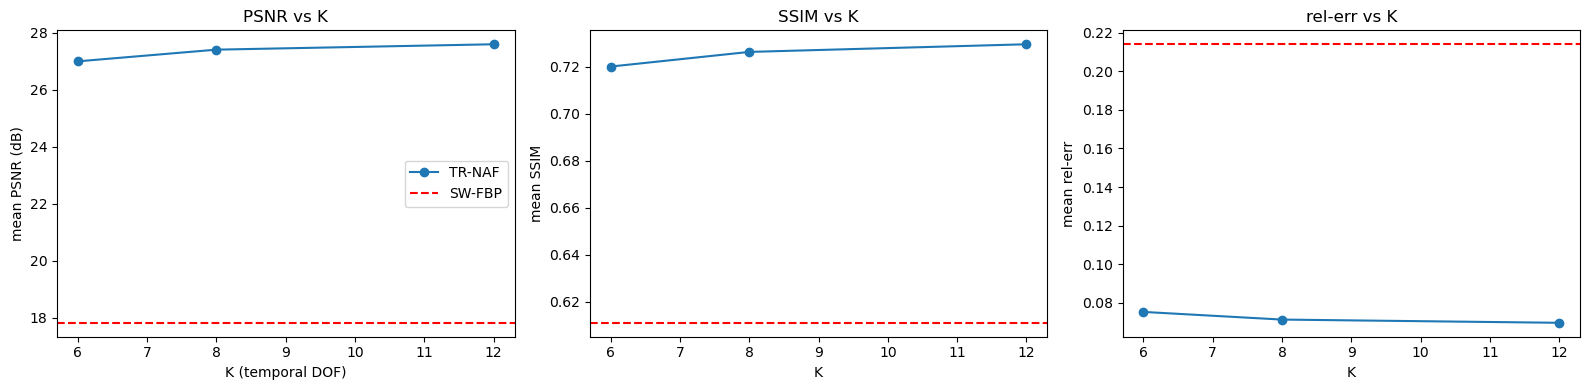

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(Ks, [runs[K]['metrics']['psnr'].mean() for K in Ks], 'o-', label='TR-NAF')
ax[0].axhline(sw_metrics['psnr'].mean(), color='r', ls='--', label='SW-FBP')
ax[0].set_xlabel('K (temporal DOF)'); ax[0].set_ylabel('mean PSNR (dB)'); ax[0].legend(); ax[0].set_title('PSNR vs K')
ax[1].plot(Ks, [runs[K]['metrics']['ssim'].mean() for K in Ks], 'o-')
ax[1].axhline(sw_metrics['ssim'].mean(), color='r', ls='--')
ax[1].set_xlabel('K'); ax[1].set_ylabel('mean SSIM'); ax[1].set_title('SSIM vs K')
ax[2].plot(Ks, [runs[K]['metrics']['rel_err'].mean() for K in Ks], 'o-')
ax[2].axhline(sw_metrics['rel_err'].mean(), color='r', ls='--')
ax[2].set_xlabel('K'); ax[2].set_ylabel('mean rel-err'); ax[2].set_title('rel-err vs K')
plt.tight_layout(); plt.show()

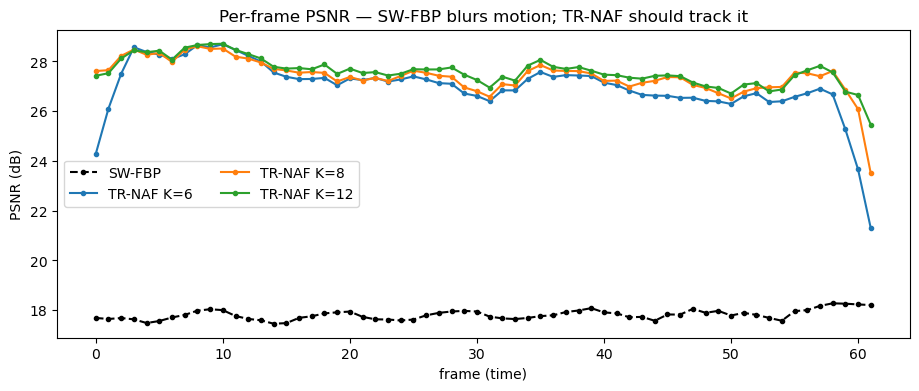

In [6]:
# Per-frame PSNR across the scan: does quality hold up as the object evolves?
plt.figure(figsize=(11, 4))
fr = np.arange(len(true_vols))
plt.plot(fr, sw_metrics['psnr'], 'k--o', ms=3, label='SW-FBP')
for K in Ks:
    plt.plot(fr, runs[K]['metrics']['psnr'], '-o', ms=3, label=f'TR-NAF K={K}')
plt.xlabel('frame (time)'); plt.ylabel('PSNR (dB)'); plt.legend(ncol=2)
plt.title('Per-frame PSNR — SW-FBP blurs motion; TR-NAF should track it'); plt.show()

## 4. Slice montage — GT vs SW-FBP vs TR-NAF across time
Pick the best K by mean PSNR.

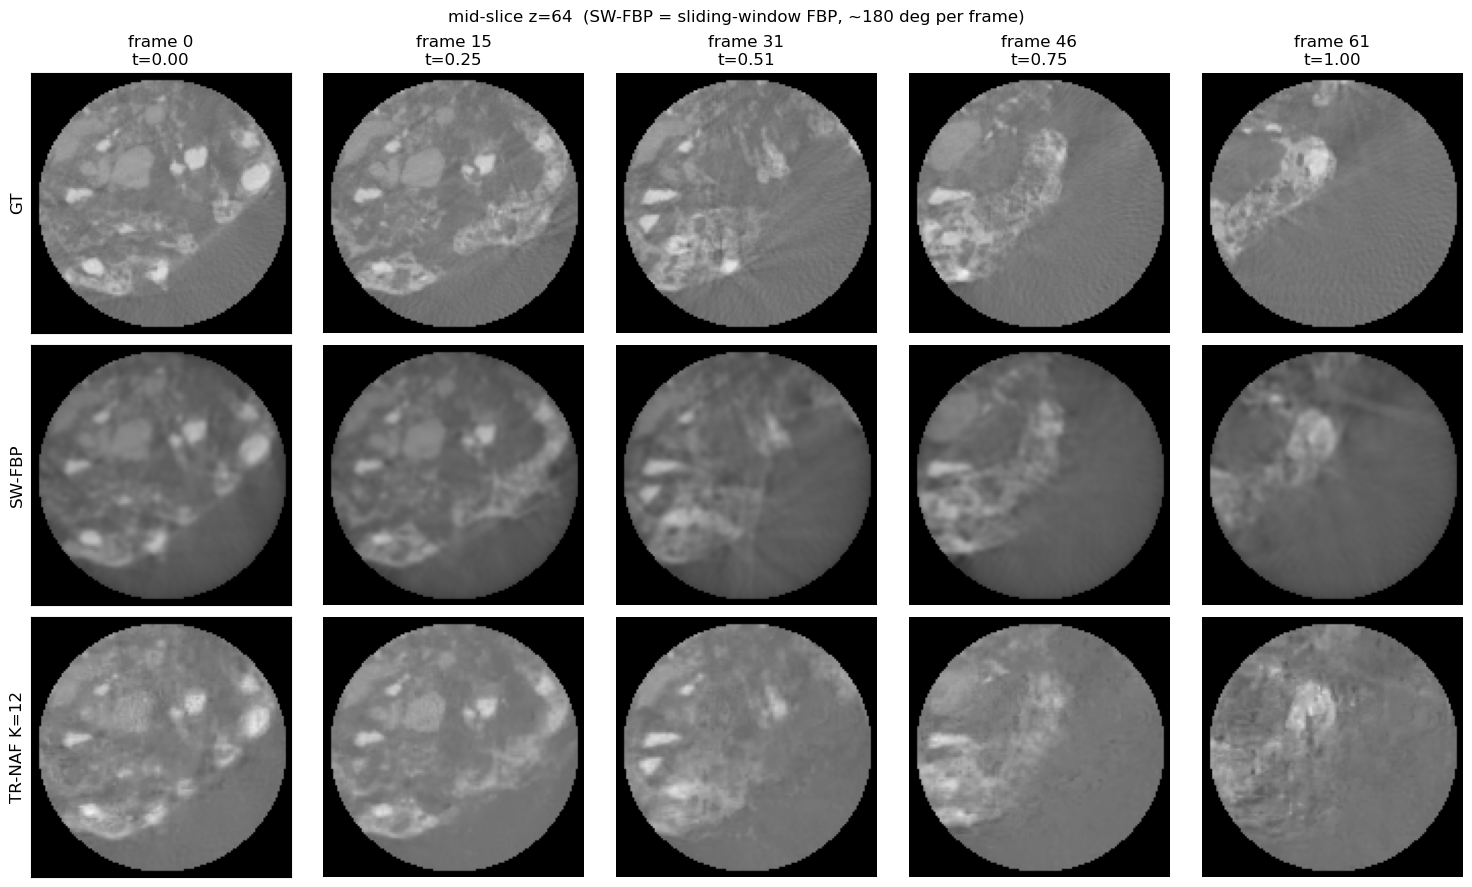

In [7]:
bestK = max(Ks, key=lambda K: runs[K]['metrics']['psnr'].mean())
z = CUBE // 2
picks = [0, len(true_vols)//4, len(true_vols)//2, 3*len(true_vols)//4, len(true_vols)-1]
recon = runs[bestK]['recon']
vmax = float(torch.stack(true_vols)[:, :, mask].max())

rows_lbl = ['GT', 'SW-FBP', f'TR-NAF K={bestK}']
fig, axes = plt.subplots(3, len(picks), figsize=(3*len(picks), 9))
for c, fi in enumerate(picks):
    imgs = [true_vols[fi][z], sw_vols[fi][z], recon[fi][z]]
    for r, im in enumerate(imgs):
        axes[r, c].imshow((im*mask).cpu(), vmin=0, vmax=vmax); axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(f'frame {fi}\nt={times[fi]:.2f}')
        if c == 0: axes[r, c].set_ylabel(rows_lbl[r], rotation=90, size=12)
for r in range(3):
    axes[r, 0].axis('on'); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(rows_lbl[r], size=12)
plt.suptitle(f'mid-slice z={z}  (SW-FBP = sliding-window FBP, ~180 deg per frame)'); plt.tight_layout(); plt.show()

## 5. Error maps (|recon - GT|) for the best K

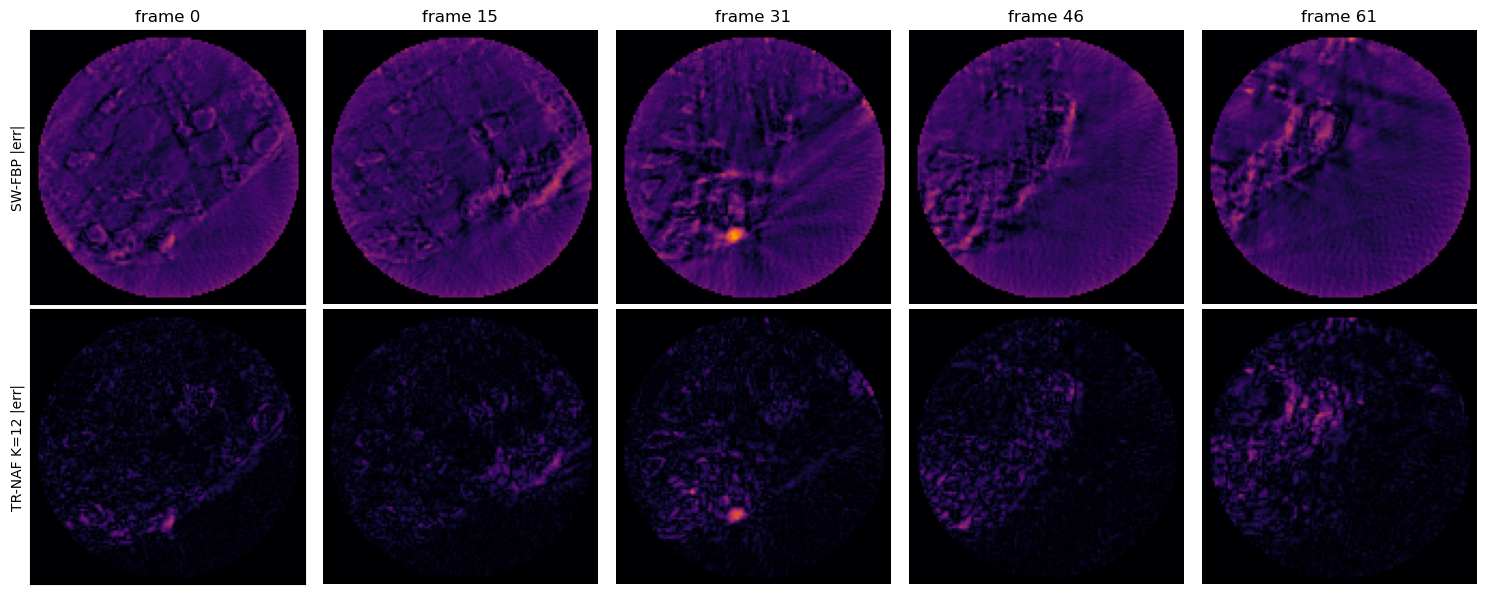

In [8]:
fig, axes = plt.subplots(2, len(picks), figsize=(3*len(picks), 6))
for c, fi in enumerate(picks):
    e_sw = ((sw_vols[fi][z]-true_vols[fi][z]).abs()*mask).cpu()
    e_tr = ((recon[fi][z]-true_vols[fi][z]).abs()*mask).cpu()
    axes[0, c].imshow(e_sw, cmap='inferno', vmin=0, vmax=vmax*0.6); axes[0, c].axis('off')
    axes[1, c].imshow(e_tr, cmap='inferno', vmin=0, vmax=vmax*0.6); axes[1, c].axis('off')
    axes[0, c].set_title(f'frame {fi}')
axes[0,0].set_ylabel('SW-FBP err'); axes[1,0].set_ylabel(f'TR-NAF K={bestK} err')
for r,l in enumerate(['SW-FBP |err|', f'TR-NAF K={bestK} |err|']):
    axes[r,0].axis('on'); axes[r,0].set_xticks([]); axes[r,0].set_yticks([]); axes[r,0].set_ylabel(l)
plt.tight_layout(); plt.show()

## 6. Per-voxel temporal curves
The core claim: each voxel follows a smooth curve in time. Pick the voxels whose
GT changes most across the scan and compare the reconstructed curve to GT.

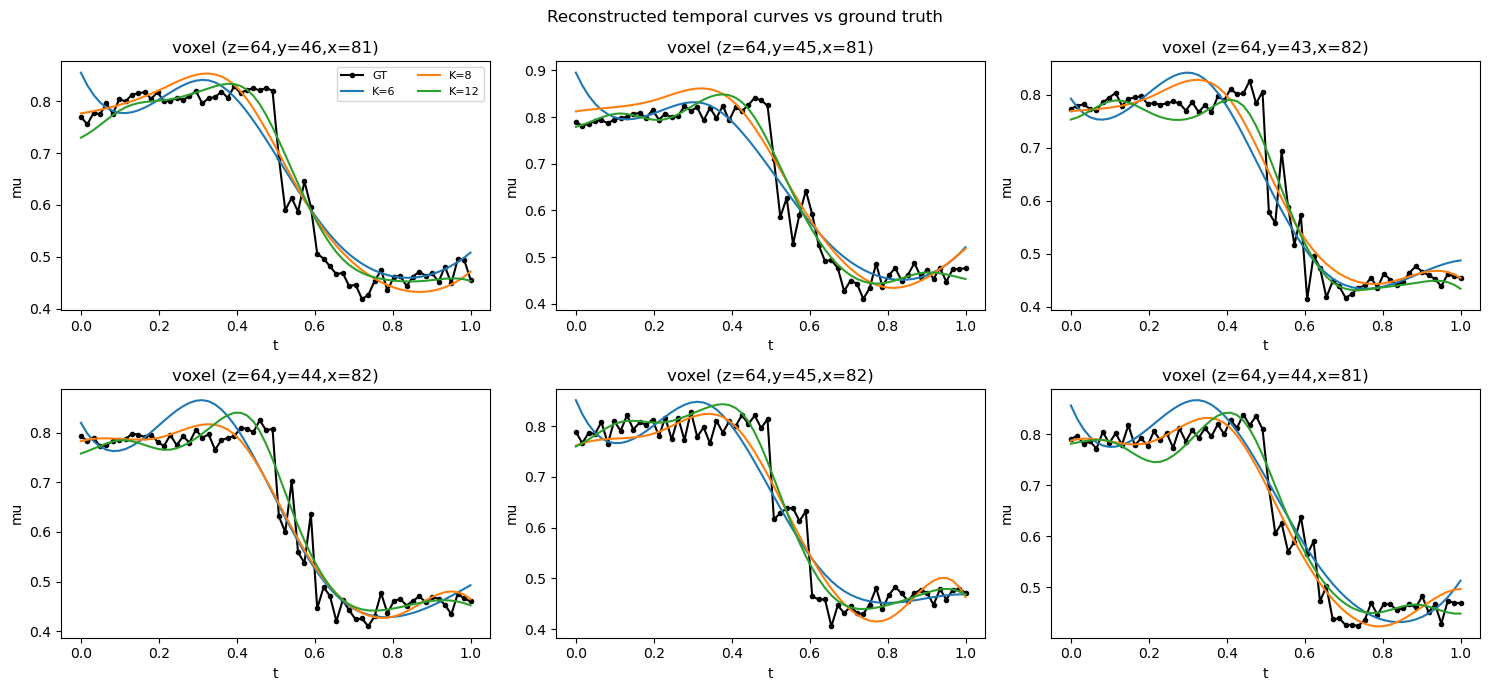

In [9]:
gt_stack = torch.stack(true_vols)            # (T, X, Y, Z)
var = gt_stack.var(0)                          # temporal variance per voxel
# restrict to masked region on the mid-slice for interpretable picks
vslice = var[z].clone(); vslice[~mask] = 0
flat = torch.topk(vslice.flatten(), 6).indices
coords = [(z, int(i//CUBE), int(i%CUBE)) for i in flat.cpu()]

recon_stack = {K: torch.stack(runs[K]['recon']) for K in Ks}   # (T,X,Y,Z)
t = np.array(times)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (zz,yy,xx) in zip(axes.ravel(), coords):
    ax.plot(t, gt_stack[:, zz, yy, xx].cpu(), 'k-o', ms=3, label='GT')
    for K in Ks:
        ax.plot(t, recon_stack[K][:, zz, yy, xx].cpu(), '-', label=f'K={K}')
    ax.set_title(f'voxel (z={zz},y={yy},x={xx})'); ax.set_xlabel('t'); ax.set_ylabel('mu')
axes[0,0].legend(ncol=2, fontsize=8)
plt.suptitle('Reconstructed temporal curves vs ground truth'); plt.tight_layout(); plt.show()

## 7. Training loss curves

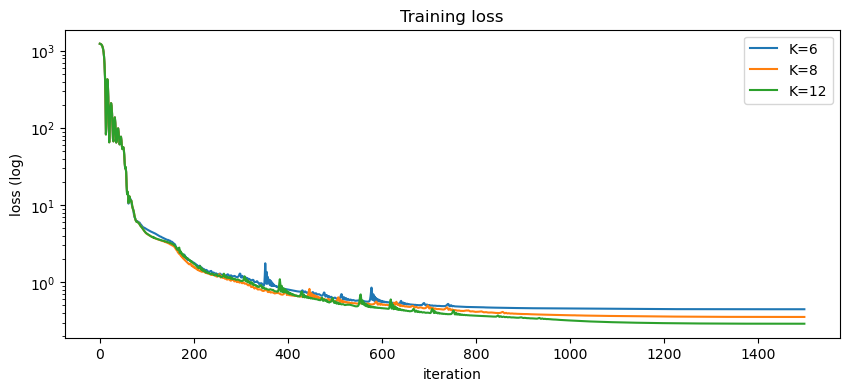

In [10]:
plt.figure(figsize=(10,4))
for K in Ks:
    plt.semilogy(runs[K]['losses'], label=f'K={K}')
plt.xlabel('iteration'); plt.ylabel('loss (log)'); plt.legend(); plt.title('Training loss'); plt.show()

## 8. Export HEVC movies (a few slices over time)
Writes one movie per slice for `recon` (best K), `gt`, and the static `sw_fbp`
baseline — the same style as `scripts/inference_time_resolved.py`. Requires
`ffmpeg` (with libx265) on PATH.

In [11]:
from sdate.tr_naf import generate_slice_movies
movie_dir = CKPT / 'movies'
movie_Ks = sorted({bestK, max(Ks)})   # recon movies for these K; GT + SW-FBP written once
try:
    written = generate_slice_movies(movie_dir, times, gt_volumes=true_vols, sw_fbp=sw_vols,
                                    num_movie_slices=5, fps=5, crf=18)
    for K in movie_Ks:
        written += generate_slice_movies(movie_dir, times, recon_volumes=runs[K]['recon'],
                                         num_movie_slices=5, fps=5, crf=18, prefix=f'K{K}_')
    print(f'Wrote {len(written)} movies to {movie_dir} (recon K={movie_Ks} + gt + sw_fbp)')
except Exception as e:
    print(f'[movies skipped] {type(e).__name__}: {e}  (install ffmpeg to enable)')

Movies: labels=['gt', 'sw_fbp'] slices=[0, 31, 63, 95, 127] times=62 -> /myhome/sdate/checkpoints/tr_naf/212_mid_skip0_pad/movies
  wrote gt_slice_000.mov
  wrote gt_slice_031.mov
  wrote gt_slice_063.mov
  wrote gt_slice_095.mov
  wrote gt_slice_127.mov
  wrote sw_fbp_slice_000.mov
  wrote sw_fbp_slice_031.mov
  wrote sw_fbp_slice_063.mov
  wrote sw_fbp_slice_095.mov
  wrote sw_fbp_slice_127.mov
Movies: labels=['recon'] slices=[0, 31, 63, 95, 127] times=62 -> /myhome/sdate/checkpoints/tr_naf/212_mid_skip0_pad/movies
  wrote K12_recon_slice_000.mov
  wrote K12_recon_slice_031.mov
  wrote K12_recon_slice_063.mov
  wrote K12_recon_slice_095.mov
  wrote K12_recon_slice_127.mov
Wrote 15 movies to /myhome/sdate/checkpoints/tr_naf/212_mid_skip0_pad/movies (recon K=[12] + gt + sw_fbp)


## Notes / next knobs
- **K** trades temporal detail vs angular coverage per DOF. `K=1` ≈ static (~SW-FBP sanity check).
- **`reg_temporal_max` / `temporal_anneal_frac`** control how hard/long the field is held static before motion is allowed in.
- To regenerate checkpoints with a different config, edit and rerun `scripts/tr_naf_sweep.py`.